In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading xLSTM 7B...")
xlstm_config = AutoConfig.from_pretrained("NX-AI/xLSTM-7b")
xlstm_config.step_kernel = "native"
xlstm_config.chunkwise_kernel = "chunkwise--native_autograd"
xlstm_config.sequence_kernel = "native_sequence__native"

xlstm = AutoModelForCausalLM.from_pretrained("NX-AI/xLSTM-7b", config=xlstm_config, device_map="auto")
xlstm_tokenizer = AutoTokenizer.from_pretrained("NX-AI/xLSTM-7b")
xlstm_tokenizer.pad_token = xlstm_tokenizer.eos_token


d:\A_Facultate\Diseration\code\Dissertation-code\logit_lens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading xLSTM 7B...


Loading weights: 100%|██████████| 483/483 [00:36<00:00, 13.09it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


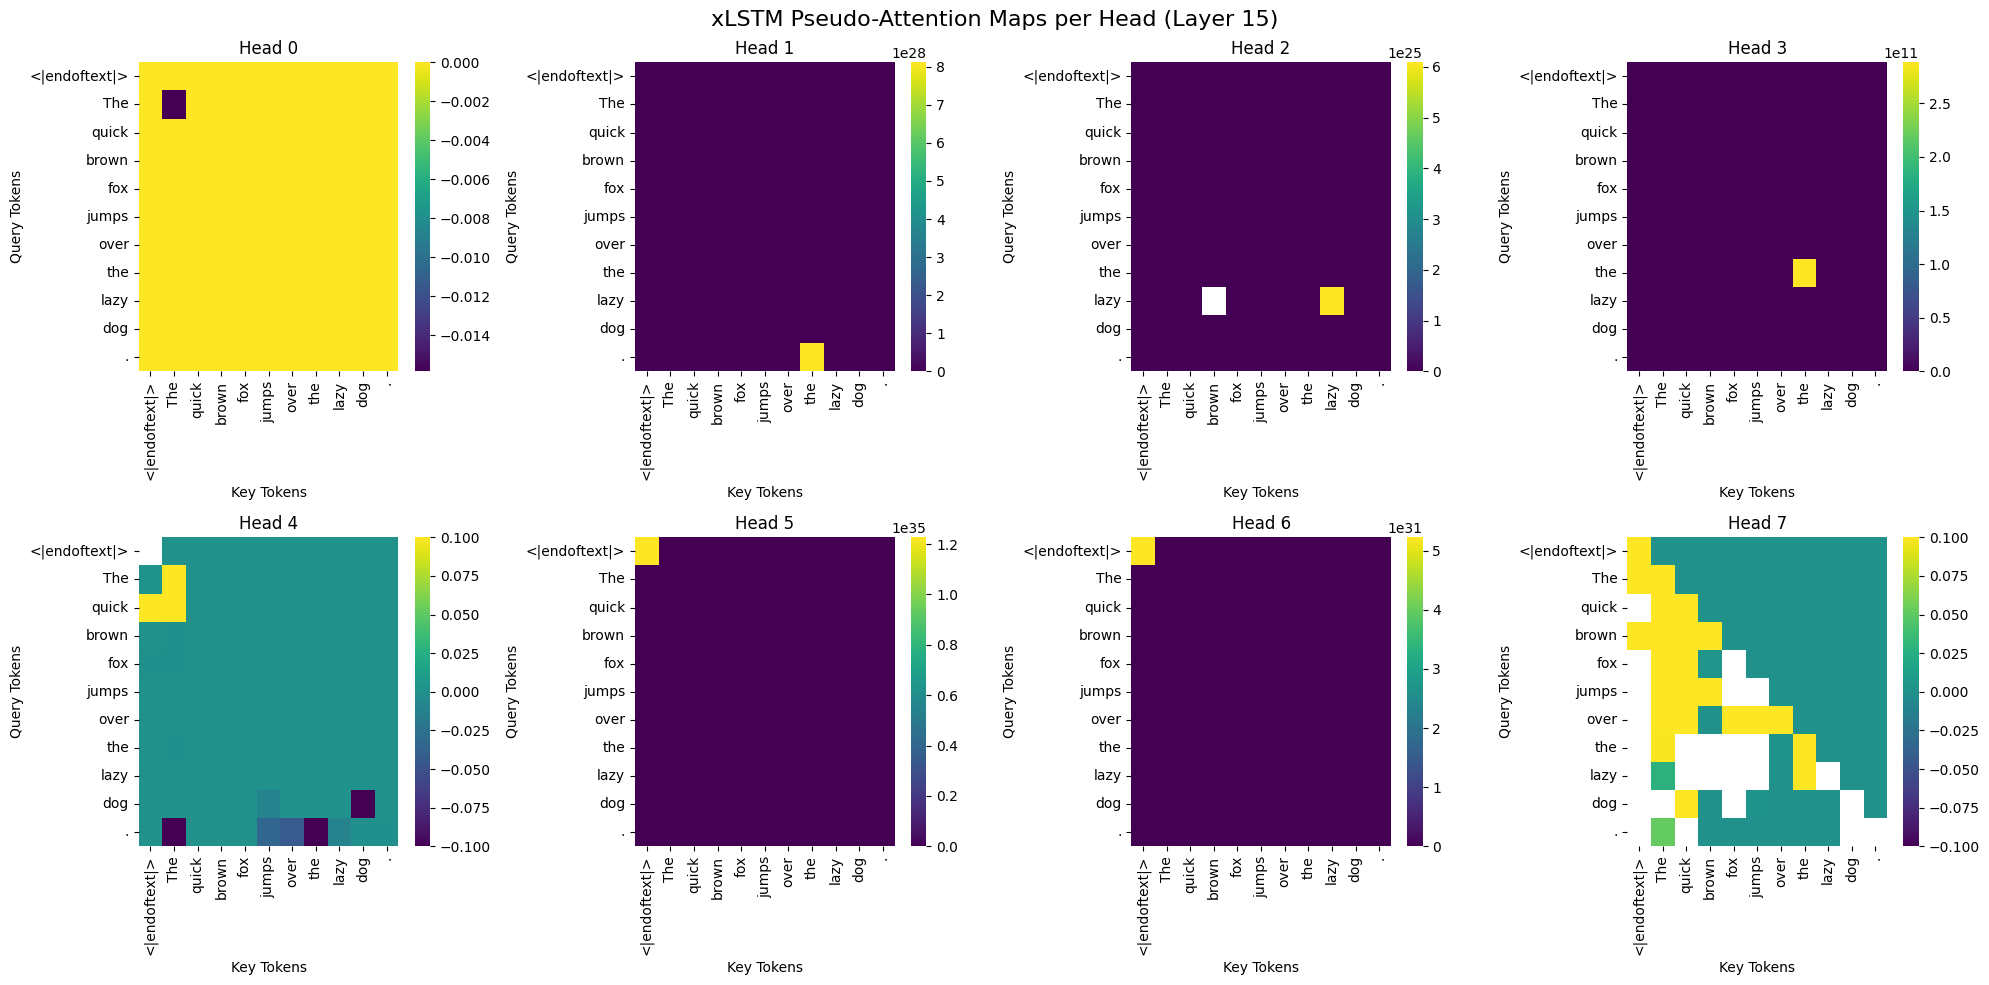

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_text = "The quick brown fox jumps over the lazy dog."

# ---------------------------------------------------------
# 1. xLSTM PSEUDO-ATTENTION EXTRACTION (Linear Attention Duality)
# ---------------------------------------------------------
# Prepare xLSTM inputs by prepending BOS token (as seen in logit_lens.ipynb)
xlstm_input_ids = xlstm_tokenizer(sample_text, return_tensors="pt")['input_ids'].to(device)
bos_id = xlstm_tokenizer.bos_token_id
if bos_id is not None:
    bos_tensor = torch.tensor([[bos_id]], device=device, dtype=xlstm_input_ids.dtype)
    xlstm_input_ids = torch.cat([bos_tensor, xlstm_input_ids], dim=1)
xlstm_tokens = xlstm_tokenizer.convert_ids_to_tokens(xlstm_input_ids[0])

# Dictionary to capture the internal tensors
captured_states = {}
def get_hook(name):
    def hook(module, input, output):
        captured_states[name] = output.detach()
    return hook

# Register forward hooks on the middle mLSTM layer (layer 15)
layer_idx = 30
mlstm = xlstm.backbone.blocks[layer_idx].mlstm_layer

h_q = mlstm.q.register_forward_hook(get_hook('q'))
h_k = mlstm.k.register_forward_hook(get_hook('k'))
h_i = mlstm.igate_preact.register_forward_hook(get_hook('igate_preact'))
h_f = mlstm.fgate_preact.register_forward_hook(get_hook('fgate_preact'))

# Forward pass to trigger hooks
with torch.no_grad():
    _ = xlstm(xlstm_input_ids)

# Remove hooks to keep the model clean
h_q.remove()
h_k.remove()
h_i.remove()
h_f.remove()

# Retrieve the captured tensors (squeeze the batch dimension)
q = captured_states['q'][0] # shape: (T, 2048)
k = captured_states['k'][0] # shape: (T, 2048)
igate = captured_states['igate_preact'][0] # shape: (T, 8)
fgate = captured_states['fgate_preact'][0] # shape: (T, 8)

T = q.shape[0]
num_heads = 8
head_dim = q.shape[-1] // num_heads # 256

# Reshape into (T, num_heads, head_dim) to process head-by-head
q = q.view(T, num_heads, head_dim)
k = k.view(T, num_heads, head_dim)

xlstm_attn_maps = []

# Compute "Linear Attention Duality" manually
for h in range(num_heads):
    q_h = q[:, h, :] # (T, 256)
    k_h = k[:, h, :] # (T, 256)
    igate_h = igate[:, h] # (T,)
    fgate_h = fgate[:, h] # (T,)
    
    # Exponential input and forget gates
    i_tilde = torch.exp(igate_h)
    f = torch.exp(fgate_h)
    
    # Compute normalizer state (n) over sequence
    n = torch.zeros(T, head_dim, device=device)
    n_prev = torch.zeros(head_dim, device=device)
    for t in range(T):
        n_t = f[t] * n_prev + i_tilde[t] * k_h[t]
        n[t] = n_t
        n_prev = n_t
        
    # Construct the T x T pseudo-attention matrix with Causal Masking
    alpha_h = torch.zeros(T, T, device=device)
    for t in range(T):
        for i in range(t + 1): # Causal masking: i <= t
            if i == t:
                f_prod = 1.0
            else:
                f_prod = torch.prod(f[i+1:t+1])
            
            # As requested: alpha[t, i] = ( exp(dot(q_t, k_i)) * i_tilde_i * prod(f_{j} from j=i+1 to t) ) / dot(n_t, q_t)
            num = torch.exp(torch.dot(q_h[t], k_h[i])) * i_tilde[i] * f_prod
            den = torch.dot(n[t], q_h[t])
            
            if den != 0:
                alpha_h[t, i] = num / den
                
    xlstm_attn_maps.append(alpha_h.cpu().numpy())
xlstm_tokens_clean = [t.replace('Ġ', '').replace(' ', '') for t in xlstm_tokens]

# ---------------------------------------------------------
# 2. VISUALIZATION PER HEAD
# ---------------------------------------------------------
import math
cols = 4
rows = math.ceil(num_heads / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()
for h in range(num_heads):
    sns.heatmap(xlstm_attn_maps[h], xticklabels=xlstm_tokens_clean, yticklabels=xlstm_tokens_clean, cmap='viridis', ax=axes[h])
    axes[h].set_title(f"Head {h}")
    axes[h].set_xlabel("Key Tokens")
    axes[h].set_ylabel("Query Tokens")
    axes[h].tick_params(axis='x', rotation=90)
    axes[h].tick_params(axis='y', rotation=0)

for h in range(num_heads, len(axes)):
    fig.delaxes(axes[h])

plt.suptitle("xLSTM Pseudo-Attention Maps per Head (Layer 15)", fontsize=16)
plt.tight_layout()
plt.show()
